## Weight-bending StyleGAN3

In this notebook we will bend the weights of a StyleGAN3 using some basic callbacks, and see the effect on the generation. Let's start! First, set up the model with the cell below, and do not forget to adapt the device on which you want to generate (l.23).

In [1]:
import re, urllib, os, sys
import torch
from pathlib import Path

torchbend_dir = Path(os.getcwd()).parent / ".." 
os.environ['TORCHBEND_DEFAULT_MODEL_DIR'] = str(torchbend_dir / "models")
models_dir = torchbend_dir / "models" / "stylegan3" 
os.makedirs(models_dir, exist_ok=True)
sys.path.append(str(torchbend_dir.resolve()))

import torchbend as tb


tb.set_output('notebook')

# download the model from website
model_path = "https://api.ngc.nvidia.com/v2/models/org/nvidia/team/research/stylegan3/1/files?redirect=true&path=stylegan3-r-ffhqu-256x256.pkl"


## How to bend a module with torchbend

Here, we will implement a simple bending operation on the model's weights : `Mask`. Bending operations consist in objects inheriting from the `BendingCallback` class, that will apply transformations to incoming values (either weights or activations). These bending operations can have parameters, that are either fixed or manually controlled through another object : `tb.BendingParameter`, that will automatically register these parameters as "manipulable" bending parameter.

Let's see that with a simple bending callback : `tb.Mask`. `tb.Mask` randomly masks (sets to 0) a proportion of the incoming input, that is controlled by its parameter `prob` : if prob equals to 0, all the values are nulled ; if the prob equals to 1, every value is kept. `tb.Mask` also has a second parameter : `seed`, that controls the random seed used to generate the masks (a different seed will output a different random mask, but a similar masking proportion).

To bend a target layer with a bending callback, we will use the `bend` callback of our interface (also working with simple modules). Bend takes the bending callback as first argument, and a set of patterns to target specific weights or activation. These patterns can be given in three different forms : 
- simple patterns, matching exactly one weight / activation (ie `synthesis.L5_84_1024.weight`)
- regexp patterns, formatted using the python [re](https://docs.python.org/3/library/re.html), preceded by a `?` character (see in the next cell)
- aliases, preceded by a `#` character (ie `#layer_out`)

Using `tb.BendingParameter` is very important because it will provide your interface to bend a model. It can be reused several times, and hence control several bending ops with a single value, be controlled separately, and most importantly be automatically exported in the `panel_ui` (we'll see that in two cells.)

Ok, let's do a simple bending operation! 

In [2]:
import torchbend as tb
from torchbend.interfaces.stylegan import BendedStyleGAN
import torchvision
from IPython.display import Image


bended = BendedStyleGAN(model_path, device=device)
inputs = bended.get_inputs(4)

# here we implement a parameter, with initial value = 1.
# prob is a masking probability, and must be between 0 and 1. 
# we set the range keyword to [-1, 1], such that it will prevent values outside of this range
c1 = tb.BendingParameter("mask", 1., range=[0., 1])
print('controllable : ', c1)

# we can print the controllable parameters of a BendingCallback subclass with the controllable_params attribute
print("controllable params of Mask : ", tb.Mask.controllable_params)
# now, we create two different callbacks, and set its probability to our controllable object, but with different seeds
cb1 = tb.Mask(prob=c1, seed=10)
cb2 = tb.Mask(prob=c1, seed=38)

# we bend different weights with our two callbacks : one masking convolution kernels, the other masking biases.
# we also add bend_graph=False to be sure that no activation is accidentally bent (sometimes, it can share common names)
bended.bend(cb1, "synthesis.L5_84_1024.weight", "synthesis.L6_84_1024.weight", bend_graph=False)
bended.bend(cb2, "synthesis.L5_84_1024.bias", "synthesis.L6_84_1024.bias", bend_graph=False)

# we can print the set of controllables
print(bended.model.controllables())


with torch.no_grad():
    out = bended.forward(**inputs)

# clamp and set the values as integers between 0 and 255 to export as an image
out = (((out[0].detach().cpu().clamp(-1, 1) + 1) / 2) * 255).to(torch.uint8)
torchvision.io.write_png(out, "out.png")
out = Image("out.png")
display(out)

NameError: name 'device' is not defined

Our image is still not bent, because our BendingParameter is still to 1. by default (and then the weight is not masked, as it keeps all its values). Now, let's change that by setting manually this parameter with `set_value` :

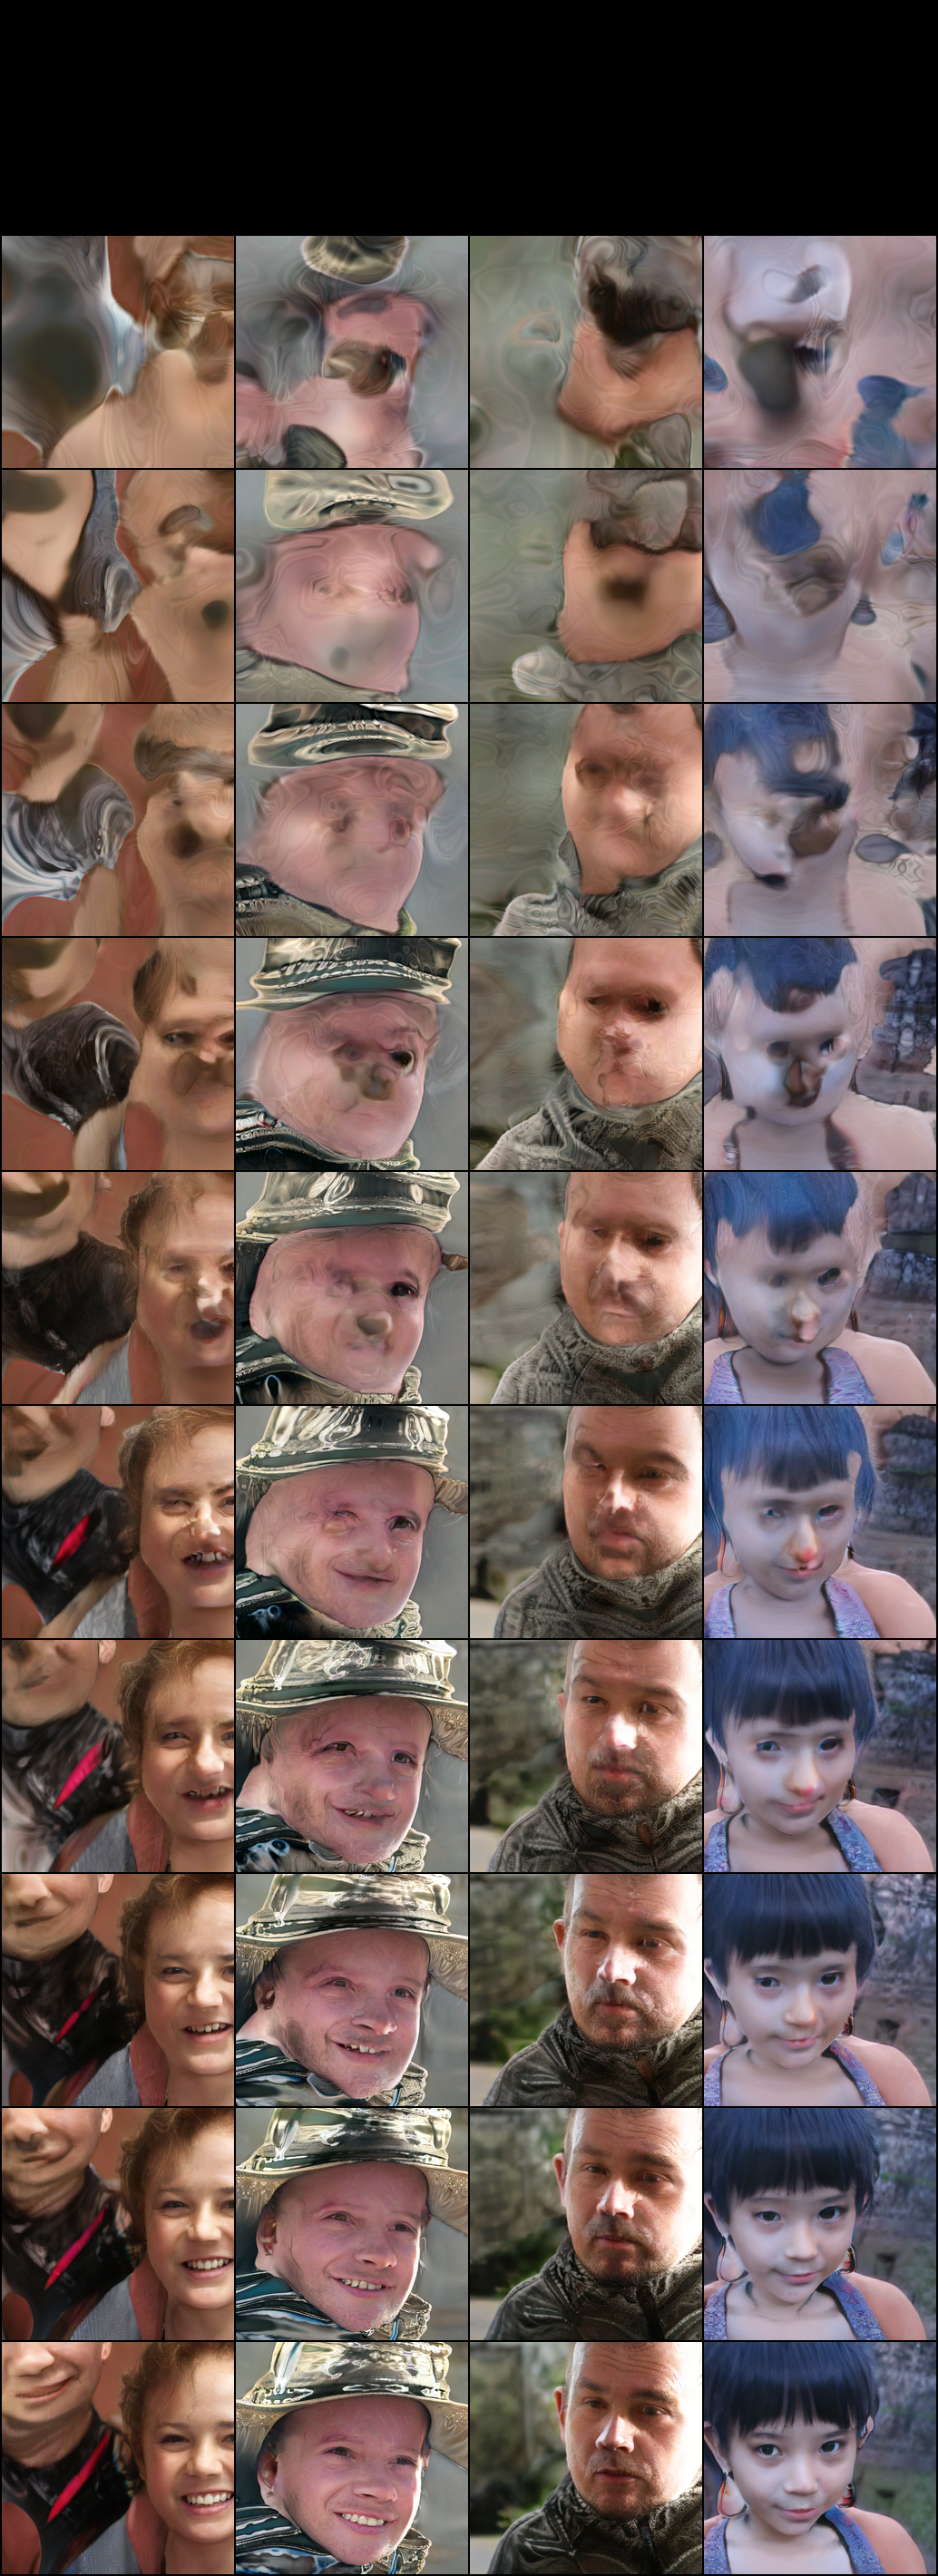

In [ ]:
bending_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

outputs = []
for mask in bending_values: 
    c1.set_value(mask)
    out = bended.forward(**inputs)
    outputs.append(out)

# concatenate the outputs
outputs = torch.cat(outputs).clamp(-1, 1)
# make a grid
out_grid = (((outputs.detach().cpu() + 1) / 2) * 255).to(torch.uint8)
out_grid = torchvision.utils.make_grid(out_grid, nrow=4)
   
torchvision.io.write_png(out_grid, "out_grid.png")
out = Image("out_grid.png")
display(out)

We can see that our image goes from a full zero (image) (the mask is nullifying everything), to the original image, and passing by different destruction steps. We can see that the effects can be quite funny and dramatic by bending only two layers. However, interacting with command lines is still not very handy ; fortunately, `interfaces` also implement additional features to allow real-time exploration of various bending operations. Let's try that.

## Interactive weight bending

This can be done with the `panel` UI extension of torchbend, that allows to automatically retrive `BendingParameter` from callbacks and provide an interactive interface for easy bending search. There, we will try other bending units : `Affine`, that allows to scale and biasing the weights, `Normal`, allowing to add some noise, and `Permute`, that randomly permutes the channels of the kernel weights.

**Note 1** : if your computer is fast enough, you can set realtime=True l.43 to update the generation in real time. Don't be too fast though, the model can take some time to generate and will queue all the requests sent by moving a slider. 

**Note 2** : by sending `bend_affine_layers = True`, you can try to bend the modulations of the kernel instead of the trained kernel to see the difference!

In [ ]:
import torchbend as tb
from torchbend.interfaces.stylegan import BendedStyleGAN
from torchbend.ui.panel import panel_generation_ui
import torchvision
from IPython.display import Image, display

import panel as pn
pn.extension()


bended.reset()

target_layer = 8
bend_affine_layers = False

inputs = bended.get_inputs(4)

c1 = tb.BendingParameter("mask", 1., range=[0., 1.])
c2 = tb.BendingParameter("seed", 0, range=[0, 1024])
cb_mask_kernels = tb.OrderedMask(prob = c1, seed = c2)

c3 = tb.BendingParameter("scale", 1., range=[-5, 5])
c4 = tb.BendingParameter("bias", 0., range=[-5, 5])
cb_affine_kernels = tb.Affine(scale=c3, bias=c4)

c5 = tb.BendingParameter("noise", 0., range=[0., 5.])
cb_noise_kernels = tb.Normal(std=c5)

c6 = tb.BendingParameter("permute_seed", -1, range=[-1, 1024])
cb_permute_kernels = tb.Permute(seed=c6, dim=0)

target_weight = rf"?synthesis.L{target_layer}[0-9_]+.affine.(weight|bias)" if bend_affine_layers else rf"?synthesis.L{target_layer}[0-9_]+.(weight|bias)"

bended.bend(cb_mask_kernels, target_weight, bend_graph=False)
bended.bend(cb_affine_kernels, target_weight, bend_graph=False)
bended.bend(cb_noise_kernels, target_weight, bend_graph=False)
bended.bend(cb_permute_kernels, target_weight, bend_graph=False)


print(bended.model.bended_weights)


panel = panel_generation_ui(bended, realtime=True, input=(tuple(), inputs), script=False, norm_fn=lambda x: (x.clamp(-1, 1) + 1) / 2)
panel


{'synthesis.L8_148_512.weight': [OrderedMask(prob=1.000), Affine(scale=1.0000, bias=0.0000), Normal(std=0.000, seed=0), Permute(dim=0)], 'synthesis.L8_148_512.bias': [OrderedMask(prob=1.000), Affine(scale=1.0000, bias=0.0000), Normal(std=0.000, seed=0), Permute(dim=0)]}


BokehModel(combine_events=True, render_bundle={'docs_json': {'9628a007-98fd-4d67-9094-f51a15731361': {'version…